0.Nível 1

Faça a conexão em Python com o MySQL Workbench para carregar todas as informações que você tem nas tabelas.

Você realizará uma visualização para cada exercício. Comente o que lhe chama a atenção na representação gráfica desta variável, justifique a escolha do gráfico e interprete os resultados com base nos seus dados.



pip install pandas
pip install matplotlib
python -m pip install --upgrade pip
python -m pip install ipykernel -U --force-reinstall
pip install numpy
pip install mysql-connector-python

después hice un bucle para crear mis dataframes


HE MODIFICADO UNA COLUMNA EM EL DATAFRAME DF_PRODUCTS ['PRICE']


In [2]:
import matplotlib as plt
import pandas as pd
import mysql.connector

connection = mysql.connector.connect(user='root', password='6933Cultura',
                                      host='127.0.0.1',
                                      database='empresas')

cursor = connection.cursor()
cursor.execute("SHOW TABLES")

# Lista de todas as tabelas no banco de dados
tables = cursor.fetchall()

# Criar DataFrames dinamicamente com base nos nomes das tabelas
for table in tables:
    table_name = table[0]  # Nome da tabela (tuple, por isso usamos [0])
    query = f"SELECT * FROM {table_name}"
    df = pd.read_sql(query, connection)
    
    # Atribuir o DataFrame a uma variável com o nome da tabela
    globals()[f"df_{table_name}"] = df

# Fechar o cursor e a conexão
cursor.close()
connection.close()

# Mostrar os DataFrames criados
for table in tables:
    table_name = table[0]
    df = globals().get(f"df_{table_name}")
    print(f"\nDataFrame for table: {table_name}")
    print(df.head().to_string())


df_products['price'] = df_products['price'].str.replace('$', '', regex=False)
df_products['price'] = pd.to_numeric(df_products['price'])

# QUITAR EL SIMBOLO ($) Y DESPUES CONVERTILO EN FLOAT 

pd.options.mode.copy_on_write = True 


DataFrame for table: companies
  company_id                 company_name           phone                             email        country                         website
0     b-2222    Ac Fermentum Incorporated  06 85 56 52 33  donec.porttitor.tellus@yahoo.net        Germany      https://instagram.com/site
1     b-2226     Magna A Neque Industries  04 14 44 64 62       risus.donec.nibh@icloud.org      Australia    https://whatsapp.com/group/9
2     b-2230                  Fusce Corp.  08 14 97 58 85              risus@protonmail.edu  United States  https://pinterest.com/sub/cars
3     b-2234    Convallis In Incorporated  06 66 57 29 50                mauris.ut@aol.couk        Germany        https://cnn.com/user/110
4     b-2238  Ante Iaculis Nec Foundation  08 23 04 99 53       sed.dictum.proin@outlook.ca    New Zealand    https://netflix.com/settings

DataFrame for table: credit_cards
         id  user_id                          iban                 pan   pin  cvv                  

C:\Users\Lucan Vieira\AppData\Local\Temp\ipykernel_14788\2676567070.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)



- Exercício 1
Uma variável numérica.

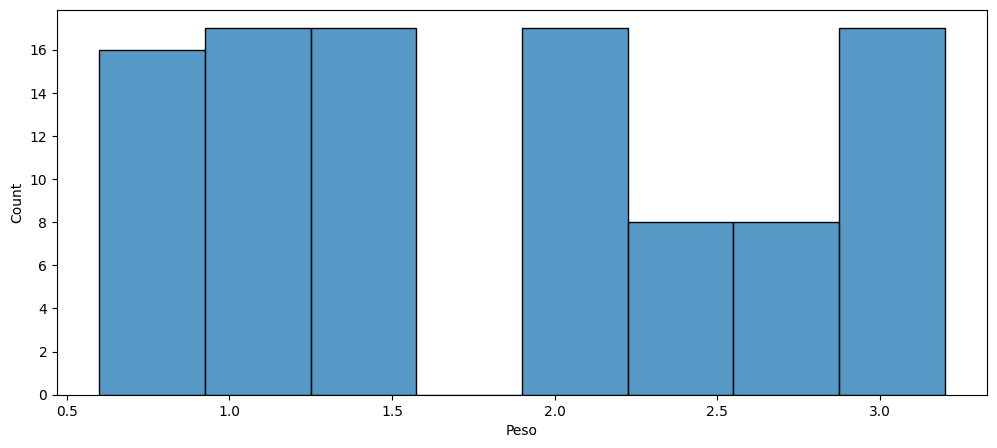

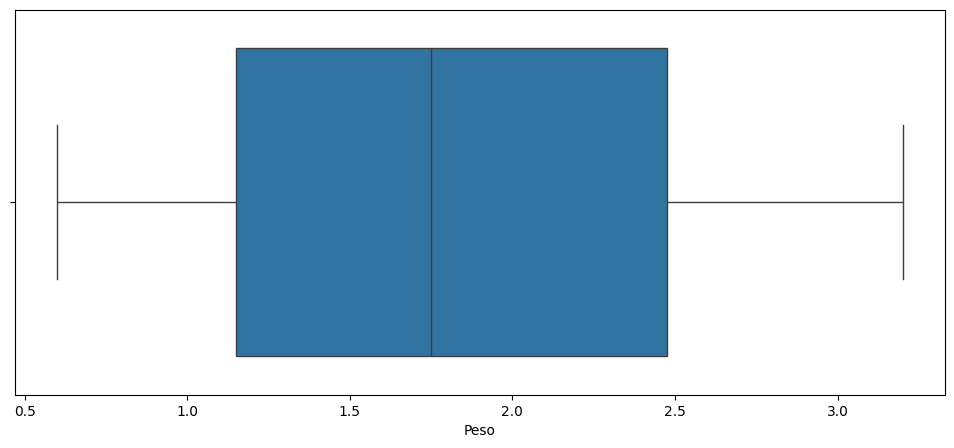

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


plt.figure(figsize=(12,5))
sns.histplot(data=df_products, x="weight")
plt.xlabel('Peso')

plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=df_products, x="weight")
plt.xlabel('Peso')

plt.show()



- Exercício 2
Duas variáveis ​​numéricas.

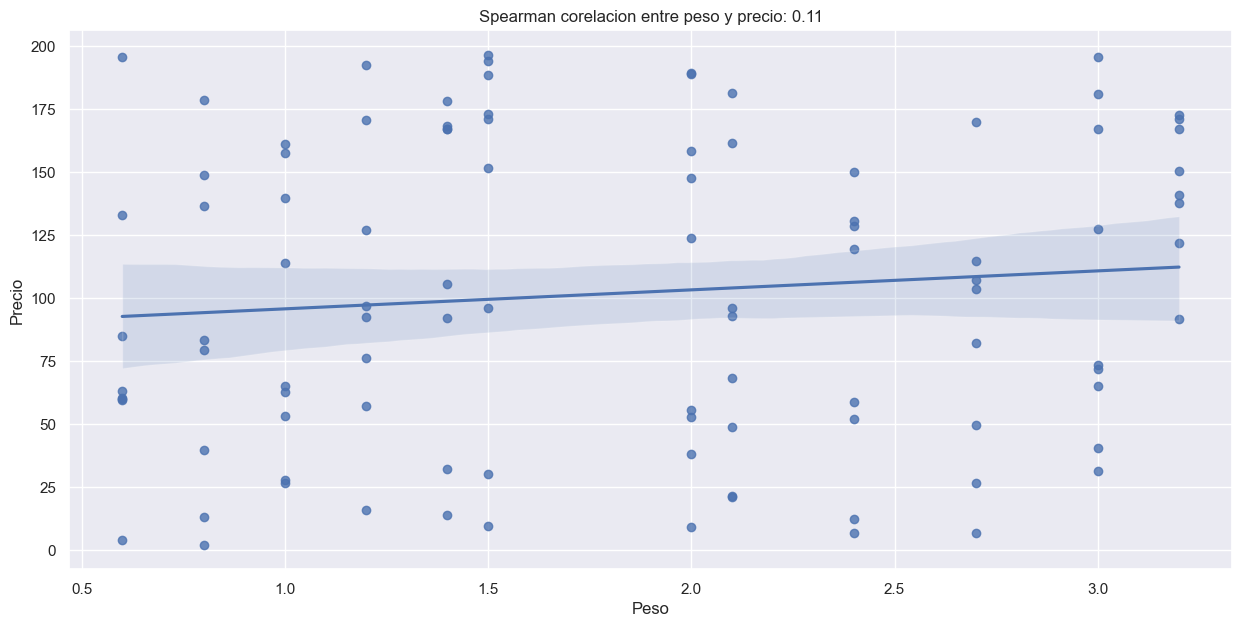

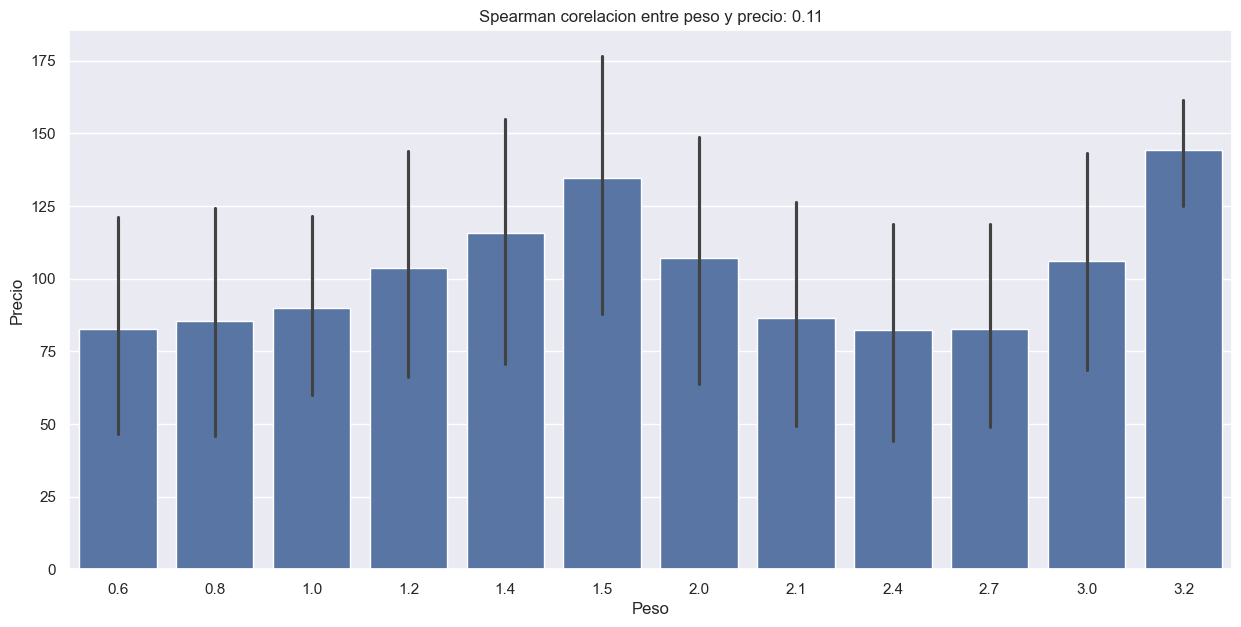

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



spearman_corr = df_products[['weight', 'price']].corr(method='spearman')

sns.set_theme(style='darkgrid')
plt.figure(figsize=(15,7))
sns.regplot(data=df_products, x="weight", y='price')
plt.xlabel('Peso')
plt.ylabel('Precio')
plt.title(f'Spearman corelacion entre peso y precio: {spearman_corr.iloc[0, 1]:.2f}')
plt.show()




sns.set_theme(style='darkgrid')
plt.figure(figsize=(15, 7))
sns.barplot(data=df_products, x="weight", y="price")
plt.xlabel('Peso')
plt.ylabel('Precio')
plt.title(f'Spearman corelacion entre peso y precio: {spearman_corr.iloc[0, 1]:.2f}')
plt.show()





- Exercício 3
Uma variável categórica.

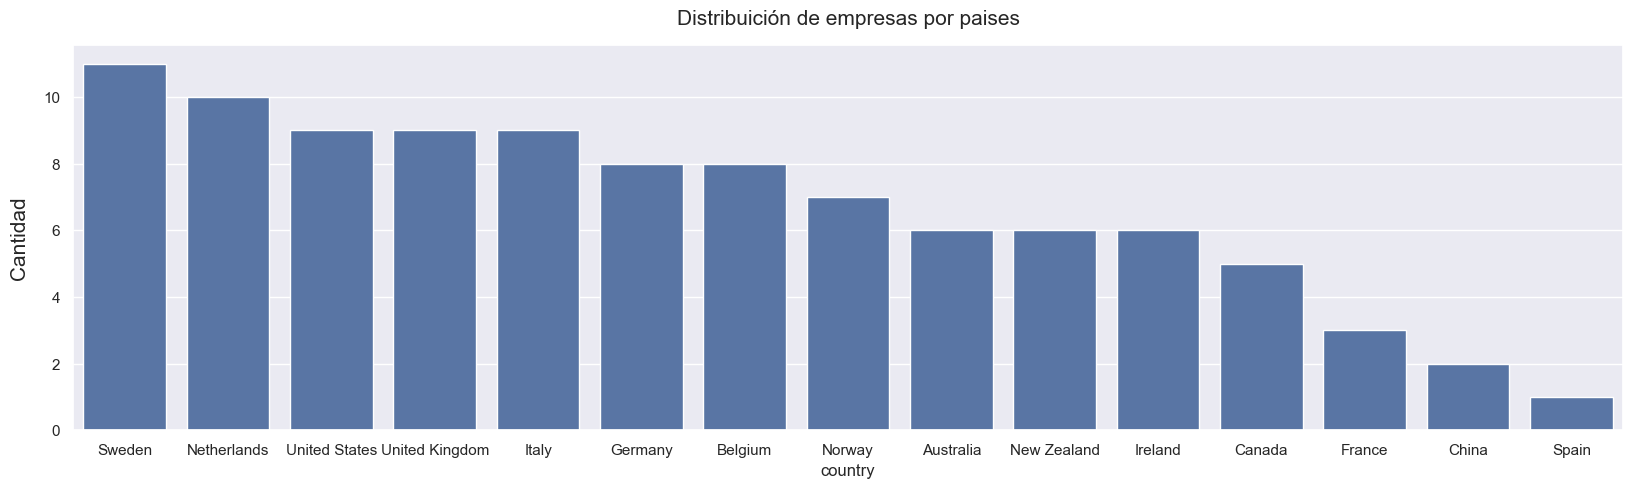

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


country_counts = df_companies['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']

plt.figure(figsize=(20, 5)) 
sns.barplot(data=country_counts, x='country', y='count')
plt.title('Distribuición de empresas por paises', fontsize=15, pad=15)
plt.ylabel('Cantidad', fontsize=15, labelpad=10)
plt.show()

fig = px.sunburst(country_counts, path=['country'], values='count')
fig.update_traces(textinfo="label+percent entry", hovertemplate="País: %{label}<br>Cantidad: %{value}")
fig.update_layout(title="Distribución de empresas por país")

fig.show()



- Exercício 4
Uma variável categórica e uma variável numérica.

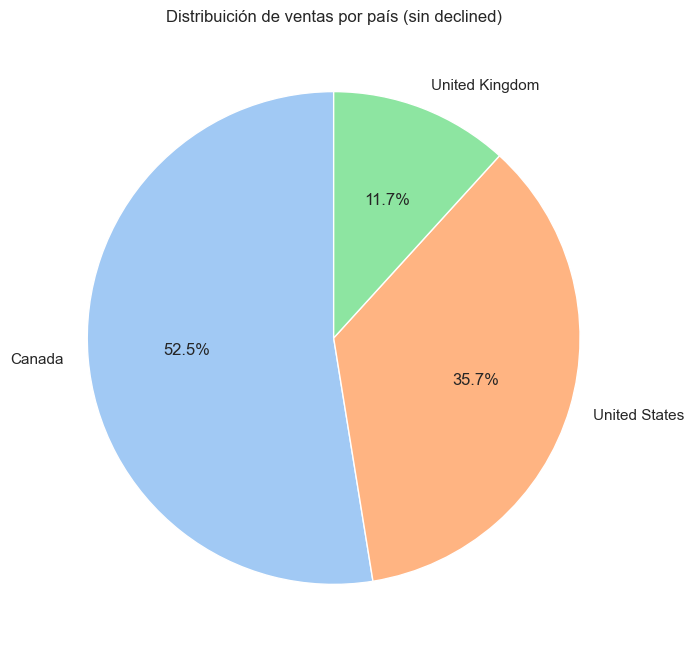

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_join_trans_user = pd.merge(df_transactions, df_users, left_on='user_id', right_on='id', how='outer')



df_filtered = df_join_trans_user[df_join_trans_user['declined'] != 1]


df_country_amount = df_filtered.groupby('country')['amount'].sum().reset_index()


df_country_amount_sorted = df_country_amount.sort_values(by='amount', ascending=False)

plt.figure(figsize=(8, 8))

# Criando o gráfico de pizza
plt.pie(df_country_amount_sorted['amount'], labels=df_country_amount_sorted['country'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))

# Título
plt.title('Distribuición de ventas por país (sin declined)')

# Mostrar o gráfico
plt.show()




- Exercício 5
Duas variáveis ​​categóricas.

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df_us_tr = pd.merge(df_users, df_transactions, left_on='id', right_on='user_id', how='outer')
df_total = df_us_tr.groupby(['country', 'city'])['amount'].sum().reset_index()


fig = px.treemap(df_total,
                 path=['country', 'city'],  
                 values='amount',
                 color='amount',
                 color_continuous_scale='Viridis',
                 title='Gasto total por país e cidade')
fig.show()

<Figure size 1200x800 with 0 Axes>

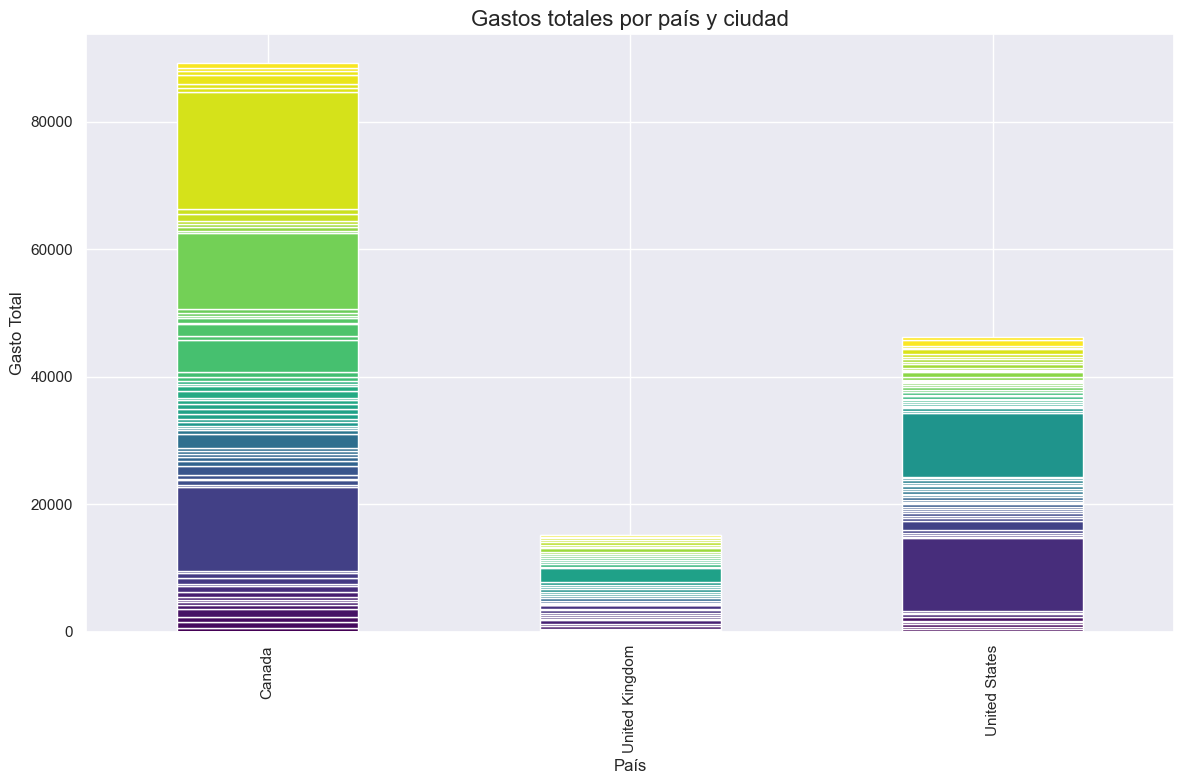

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_us_tr = pd.merge(df_users, df_transactions, left_on='id', right_on='user_id', how='outer')
df_total = df_us_tr.groupby(['country', 'city'])['amount'].sum().reset_index()

df_pivot = df_total.pivot_table(index='country', columns='city', values='amount', aggfunc='sum', fill_value=0)

plt.figure(figsize=(12, 8))
df_pivot.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')

plt.title('Gastos totales por país y ciudad', fontsize=16)
plt.xlabel('País', fontsize=12)
plt.ylabel('Gasto Total', fontsize=12)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()


- Exercício 6
Três variáveis.

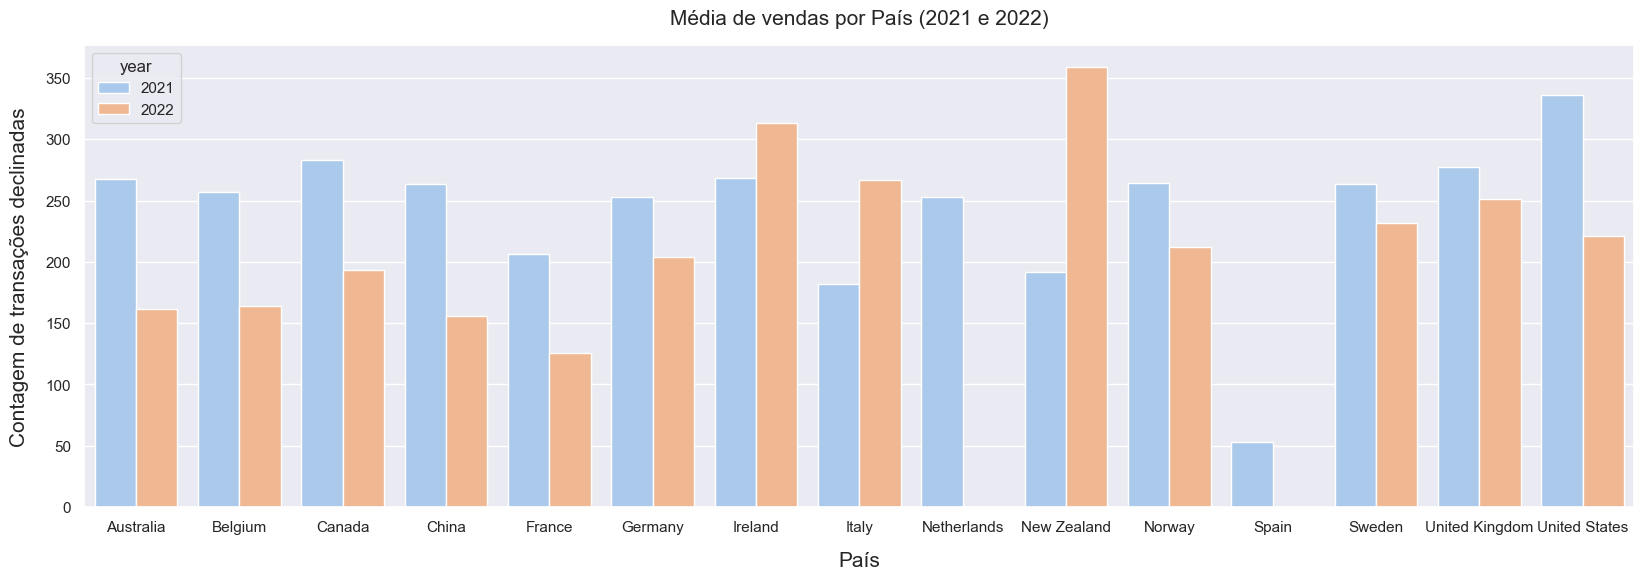

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_tran_comp = pd.merge(df_transactions, df_companies, left_on='business_id', right_on='company_id', how='outer')

df_seleccion = df_tran_comp[['country', 'timestamp', 'declined', 'amount']]

df_seleccion['year'] = df_seleccion['timestamp'].dt.year

df_filtered = df_seleccion[df_seleccion['year'].isin([2021, 2022])]

df_tc = df_filtered.groupby(['country', 'year'])['amount'].mean().reset_index()


plt.figure(figsize=(20, 6))
sns.barplot(data=df_tc, x='country', y='amount', hue='year', palette='pastel')
sns.set_theme(style='darkgrid')
plt.title('Média de vendas por País (2021 e 2022)', fontsize=15, pad=15)
plt.xlabel('País', fontsize=15, labelpad=12)
plt.ylabel('Contagem de transações declinadas', fontsize=15, labelpad=12)



plt.show()


,transaction_id,product_id
0,02C6201E-D90A-1859-B4EE-88D2986D3B02,1
1,122DC333-E19F-D629-DCD8-9C54CF1EBB9A,1
2,1753A288-9FC1-52E6-5C39-A1FFB97B0D3A,1
3,1A6CECFB-2E3A-65A3-72D9-2FDB58A1E4BA,1
4,1EA2B262-D507-AD14-4374-4D532967113F,1
...,...,...
1452,EAD89828-65AA-E817-F946-E7365972D94E,97
1453,F28E106B-5418-4667-9514-2E2A823ECC65,97
1454,F5ACD74B-4275-5AA1-2414-6EF417636B98,97
1455,F85A7D75-2778-9D75-D776-3F41A828DE88,97



- Exercício 7
Crie um gráfico de Pairplot.

In [30]:
df_products


,id,product_name,price,colour,weight,warehouse_id
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4
1,2,Tarly Stark,9.24,#919191,2.0,WH-3
2,3,duel tourney Lannister,171.13,#d8d8d8,1.5,WH-2
3,4,warden south duel,71.89,#111111,3.0,WH-1
4,5,skywalker ewok,171.22,#dbdbdb,3.2,WH-0
...,...,...,...,...,...,...
95,96,dooku solo,20.92,#282828,2.1,WH--91
96,97,jinn Winterfell,65.25,#bababa,1.0,WH--92
97,98,Direwolf Littlefinger,38.33,#bababa,2.0,WH--93
98,99,the duel,151.78,#212121,1.5,WH--94


In [ ]:
total_transaction_amount = df_j_ppp_ttt.groupby(by=['transaction_id'])['amount'].sum()/df_j_['transaction_id'].value_counts()

NameError: name 'merged_data' is not defined

<Figure size 2000x2000 with 0 Axes>

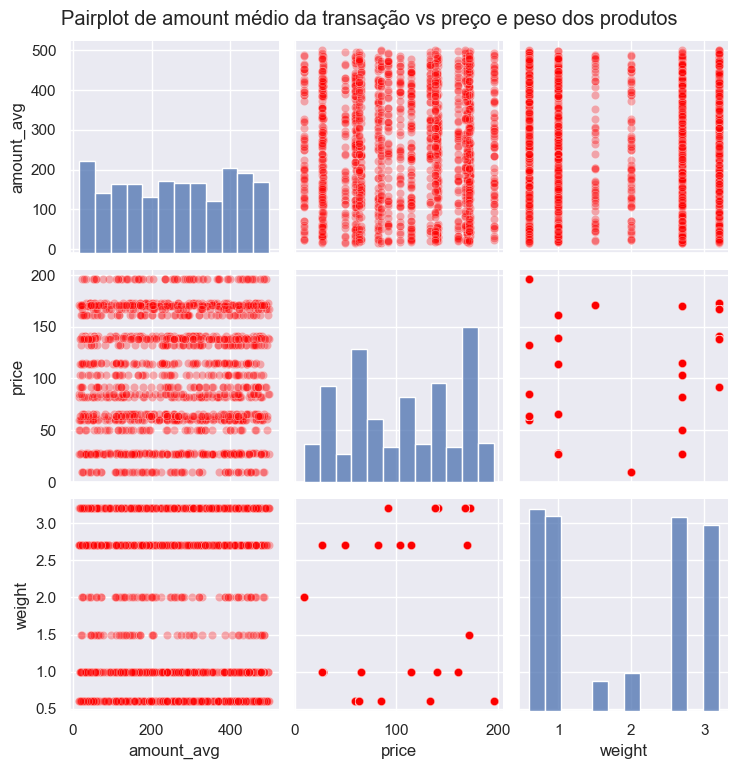

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_j_p_tp = pd.merge(df_transactions, df_transactions_products, left_on='id', right_on='transaction_id', how='outer')
df_j_ppp_ttt = pd.merge(df_j_p_tp, df_products, left_on='product_id', right_on='id', how='outer')

amount_avg = (
    df_j_ppp_ttt.groupby('transaction_id')['amount'].sum() / 
    df_j_ppp_ttt['transaction_id'].value_counts()
).rename('amount_avg')

df_j_ppp_ttt['amount_avg'] = df_j_ppp_ttt['transaction_id'].map(amount_avg)

df_pairplot = df_j_ppp_ttt[['amount_avg', 'price', 'weight']].dropna()

# Plotar
plt.figure(figsize=(20, 20)) 
sns.pairplot(df_pairplot, plot_kws={'color': 'red', 'alpha': 0.3})

plt.suptitle('Pairplot de amount médio da transação vs preço e peso dos produtos', y=1.02)
plt.show()


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_j_p_tp = pd.merge(df_transactions, df_transactions_products, left_on='id', right_on='transaction_id', how='outer')
df_j_ppp_ttt = pd.merge(df_j_p_tp, df_products, left_on='product_id', right_on='id', how='outer')

total_transaction_amount = (df_j_ppp_ttt.groupby(by=['transaction_id'])['amount'].sum()/df_j_ppp_ttt['transaction_id'].value_counts()).rename('amount_avg')

price_amount = df_j_ppp_ttt[['weight', 'price']].dropna()

df_pairplot = pd.concat[['amount_avg','price', 'weight']]

plt.figure(figsize=(20, 20)) 
sns.pairplot(df_pairplot, plot_kws={'color': 'red', 'alpha': 0.3}, ) 

plt.suptitle('Pairplot de los datos numéricos', y=1.02)

plt.show()

TypeError: 'function' object is not subscriptable

Nível 2


Exercício 1
Correlação de todas as variáveis ​​numéricas.

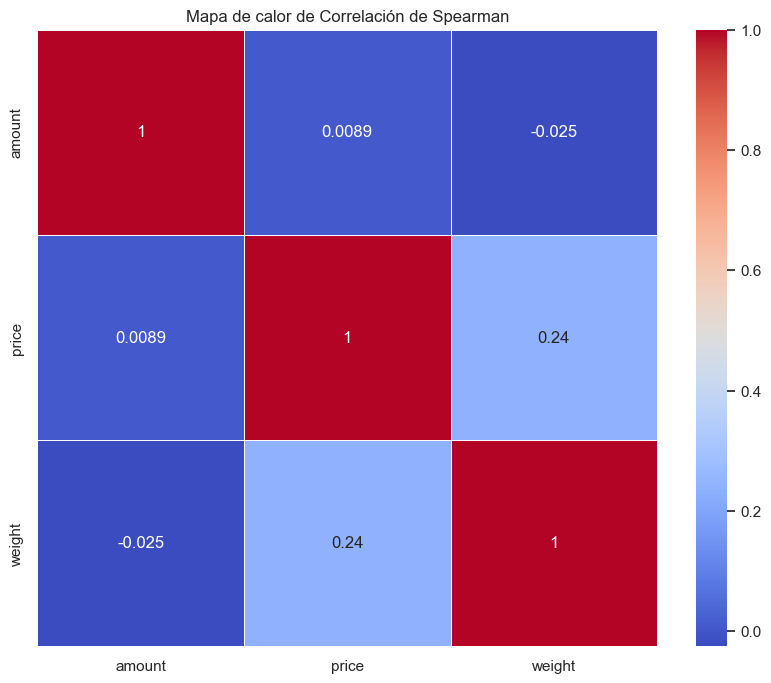

,amount,price,weight
amount,1.000000,0.008881,-0.024555
price,0.008881,1.000000,0.238089
weight,-0.024555,0.238089,1.000000


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr_num = df_pairplot.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de calor de Correlación de Spearman')
plt.show()

corr_num


Exercício 2
Implementar um jointplot.

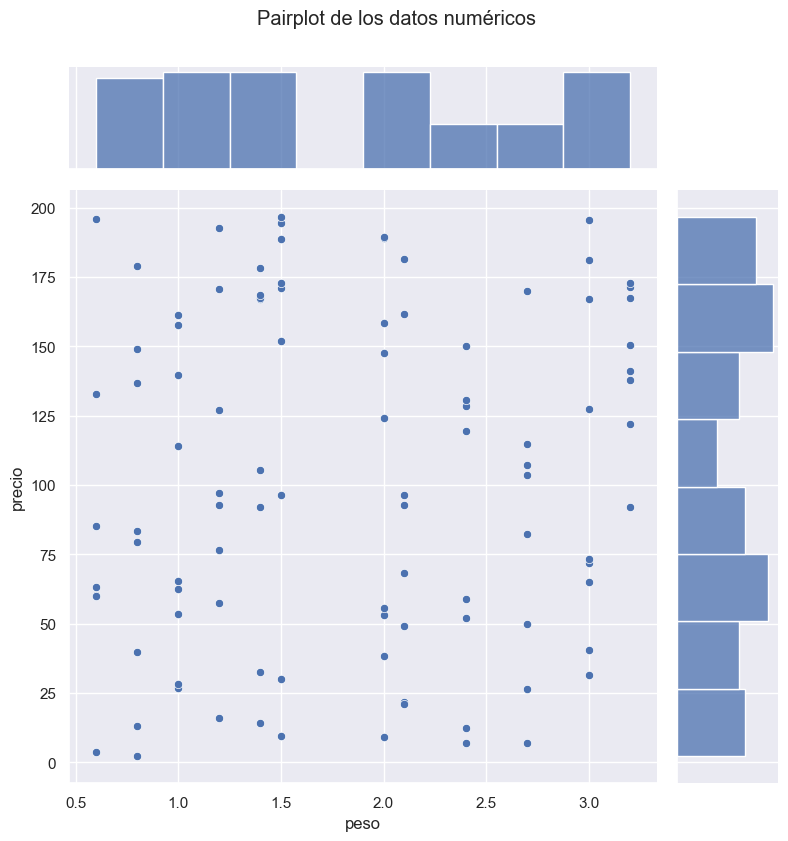

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



sns.jointplot(data=df_products, x='weight', y='price', height=8)

plt.suptitle('Pairplot de los datos numéricos', y=1.05)
plt.xlabel('peso')
plt.ylabel('precio')
plt.show()

Nível 3



Exercício 1
Implemente um violinplot combinado com outro tipo de gráfico.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df_peso = df_products.dropna(subset=['weight'])


categoria_de_peso = []

for weight in df_peso['weight']:
    if weight < 1:
        categoria_de_peso.append('0-1kg')
    elif 1 <= weight < 2:
        categoria_de_peso.append('1-2kg')
    elif weight >= 2:
        categoria_de_peso.append('>2kg')

df_peso.loc[:,'categoria_de_peso'] = pd.Categorical(categoria_de_peso, categories=['0-1kg', '1-2kg', '>2kg'], ordered=True)

plt.figure(figsize=(18, 9)) 

p = (sns.violinplot(x='categoria_de_peso', y='price', data=df_peso, density_norm='count', width=0.8, hue='categoria_de_peso',palette='pastel', inner=None))

sns.boxenplot(x='categoria_de_peso', y='price', data=df_peso, width=0.1, linewidth=5, alpha=0.3)
p.set(xlabel='Categoria de peso', ylabel='Precio' )

plt.suptitle('Violinplot | Boxplot de peso', y=1.02)

plt.show()


Exercício 2
Gera um FacetGrid para visualizar vários aspectos dos dados simultaneamente.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



plt.figure(figsize=(18, 9)) 
g = sns.FacetGrid(df_peso, col='categoria_de_peso', height=4,aspect=1)
g.map(plt.scatter, 'price', 'weight')
 
g.fig.suptitle("Distribuición de peso por precio", fontsize=12)
g.fig.subplots_adjust(top=0.80)
g.set_axis_labels('Precio', 'Peso')

plt.show()
